In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 4)

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/POWER_MODEL/DAYTON_hourly.csv')


,Datetime,DAYTON_MW
0,2004-12-31 01:00:00,1596.0
1,2004-12-31 02:00:00,1517.0
2,2004-12-31 03:00:00,1486.0
3,2004-12-31 04:00:00,1469.0
4,2004-12-31 05:00:00,1472.0


In [ ]:
data['Datetime'] = pd.to_datetime(data['Datetime'])
data = data.set_index('Datetime')
data.head()

,DAYTON_MW
Datetime,
2004-12-31 01:00:00,1596.0
2004-12-31 02:00:00,1517.0
2004-12-31 03:00:00,1486.0
2004-12-31 04:00:00,1469.0
2004-12-31 05:00:00,1472.0


## Feature Engineering

### Subtask:
Generate relevant time-series features such as lag features, rolling/moving averages, and various temporal indicators (e.g., hour of day, day of week, month, year) from the 'Datetime' index.


**Reasoning**:
I will generate new time-series features by extracting temporal components from the datetime index, creating lag features for the target variable, and calculating rolling mean features. This will enrich the dataset for the forecasting model.



In [ ]:
data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek
data['month'] = data.index.month
data['year'] = data.index.year

data['lag_1h'] = data['DAYTON_MW'].shift(1)
data['lag_24h'] = data['DAYTON_MW'].shift(24)
data['lag_48h'] = data['DAYTON_MW'].shift(48)
data['lag_168h'] = data['DAYTON_MW'].shift(168)
data['lag_336h'] = data['DAYTON_MW'].shift(336)

data['rolling_mean_24h'] = data['DAYTON_MW'].rolling(window=24).mean()
data['rolling_mean_48h'] = data['DAYTON_MW'].rolling(window=48).mean()
data['rolling_mean_168h'] = data['DAYTON_MW'].rolling(window=168).mean()

data.head()

,DAYTON_MW,hour,dayofweek,month,year,lag_1h,lag_24h,lag_48h,lag_168h,lag_336h,rolling_mean_24h,rolling_mean_48h,rolling_mean_168h
Datetime,,,,,,,,,,,,,
2004-12-31 01:00:00,1596.0,1,4,12,2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-12-31 02:00:00,1517.0,2,4,12,2004,1596.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-12-31 03:00:00,1486.0,3,4,12,2004,1517.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-12-31 04:00:00,1469.0,4,4,12,2004,1486.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-12-31 05:00:00,1472.0,5,4,12,2004,1469.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Prepare Data for EBM Training

### Subtask:
Define the target variable ('DAYTON_MW') and the engineered features. Handle any missing values introduced during feature engineering, typically by dropping or forward-filling them, to prepare the dataset for the EBM model.


**Reasoning**:
To prepare the data for EBM training, I will first handle missing values by dropping rows with NaN, then separate the target variable 'DAYTON_MW' from the features, creating 'y' for the target and 'X' for the features.



In [ ]:
data.dropna(inplace=True)
X = data.drop('DAYTON_MW', axis=1)
y = data['DAYTON_MW']

print("Shape of X after dropping NaNs:", X.shape)
print("Shape of y after dropping NaNs:", y.shape)
print("First 5 rows of X:")
print(X.head())
print("First 5 rows of y:")
print(y.head())

Shape of X after dropping NaNs: (120939, 12)
Shape of y after dropping NaNs: (120939,)
First 5 rows of X:
                     hour  dayofweek  month  year  lag_1h  lag_24h  lag_48h  \
Datetime                                                                      
2004-12-17 01:00:00     1          4     12  2004  1910.0   1964.0   1784.0   
2004-12-17 02:00:00     2          4     12  2004  2028.0   1896.0   1711.0   
2004-12-17 03:00:00     3          4     12  2004  1951.0   1859.0   1671.0   
2004-12-17 04:00:00     4          4     12  2004  1920.0   1853.0   1672.0   
2004-12-17 05:00:00     5          4     12  2004  1916.0   1867.0   1693.0   

                     lag_168h  lag_336h  rolling_mean_24h  rolling_mean_48h  \
Datetime                                                                      
2004-12-17 01:00:00    2035.0    1596.0       2084.958333       2135.270833   
2004-12-17 02:00:00    1968.0    1517.0       2087.250000       2140.270833   
2004-12-17 03:00:00    1

## Split Data into Training and Test Sets

### Subtask:
Divide the preprocessed data into training and testing sets using a time-series aware splitting method (e.g., `TimeSeriesSplit` from `sklearn.model_selection`) to maintain temporal order for accurate evaluation.


**Reasoning**:
To split the data into training and test sets while preserving the temporal order, I will use `TimeSeriesSplit`. I'll set `n_splits` to 5 and iterate through the splits, taking the last one for the final `X_train`, `X_test`, `y_train`, and `y_test`.



In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (100783, 12)
X_test shape: (20156, 12)
y_train shape: (100783,)
y_test shape: (20156,)


## Train Explainable Boosting Machine Model

### Subtask:
Initialize and train an `ExplainableBoostingRegressor` model from `interpret.glassbox` on the training data. This step will build the core forecasting model.


In [ ]:
import pickle

In [ ]:
model_filename = 'ebm_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(ebm_model, file)
print(f"EBM model saved to {model_filename}")

EBM model saved to ebm_model.pkl


**Reasoning**:
To initialize and train the Explainable Boosting Machine model, I will create an instance of `ExplainableBoostingRegressor` and then fit it using the training data `X_train` and `y_train`.



In [ ]:
ebm_model = ExplainableBoostingRegressor()
ebm_model.fit(X_train, y_train)

print("EBM model trained successfully.")

EBM model trained successfully.


## Evaluate Model Performance

### Subtask:
Predict on the test set and calculate key performance metrics such as Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to assess the forecasting accuracy of the EBM model. Additionally, plot the actual vs. predicted values to visually inspect model performance.


**Reasoning**:
I will make predictions on the test set using the trained `ebm_model` to prepare for performance evaluation.



In [ ]:
y_pred = ebm_model.predict(X_test)
print("Predictions made successfully.")

Predictions made successfully.


**Reasoning**:
I will calculate the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to quantify the model's forecasting accuracy, and then visualize a subset of the actual and predicted values to assess performance visually.



Mean Absolute Error (MAE): 32.50
Root Mean Squared Error (RMSE): 45.82


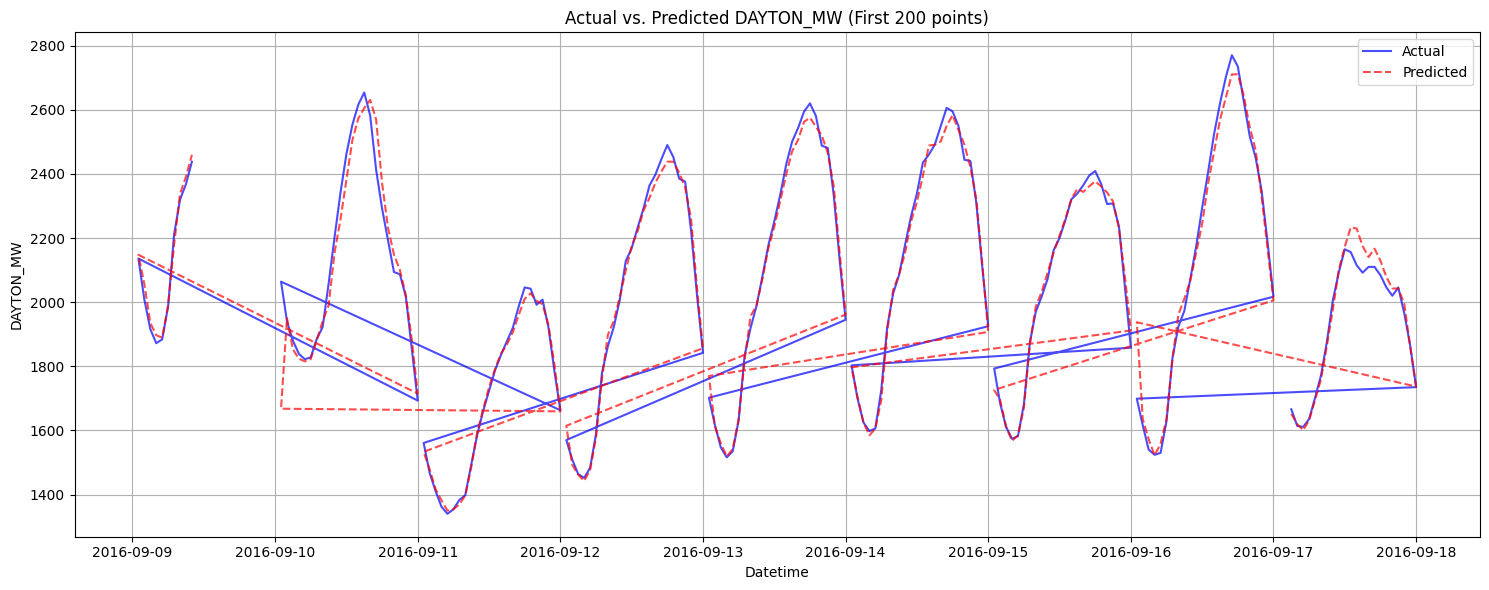

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Plot actual vs. predicted values
plt.figure(figsize=(15, 6))
plt.plot(y_test.index[:200], y_test[:200], label='Actual', color='blue', alpha=0.7)
plt.plot(y_test.index[:200], y_pred[:200], label='Predicted', color='red', alpha=0.7, linestyle='--')
plt.title('Actual vs. Predicted DAYTON_MW (First 200 points)')
plt.xlabel('Datetime')
plt.ylabel('DAYTON_MW')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Analyze and Visualize Feature Contributions

### Subtask:
Utilize the inherent visualization capabilities of Explainable Boosting Machines (e.g., `interpret.show`) to analyze and present the global and local explanations of feature contributions to the model's predictions. This will provide insights into which features drive the forecasts and how.


**Reasoning**:
I will generate and display the global explanations for the trained EBM model to understand the overall contribution of each feature.



In [ ]:
global_explainer = ebm_model.explain_global()
show(global_explainer)

**Reasoning**:
To get local explanations, I will select the first instance from the test set (`X_test` and `y_test`) to analyze how its specific prediction was influenced by the features.



In [ ]:
X_test_instance = X_test.iloc[[0]]
y_test_instance = y_test.iloc[[0]]

print("Selected X_test instance:")
print(X_test_instance)
print("\nSelected y_test instance:")
print(y_test_instance)

Selected X_test instance:
                     hour  dayofweek  month  year  lag_1h  lag_24h  lag_48h  \
Datetime                                                                      
2016-09-17 03:00:00     3          5      9  2016  1736.0   1508.0   1608.0   

                     lag_168h  lag_336h  rolling_mean_24h  rolling_mean_48h  \
Datetime                                                                      
2016-09-17 03:00:00    1703.0    1326.0          1945.875           2079.25   

                     rolling_mean_168h  
Datetime                                
2016-09-17 03:00:00        2188.470238  

Selected y_test instance:
Datetime
2016-09-17 03:00:00    1666.0
Name: DAYTON_MW, dtype: float64


**Reasoning**:
I will generate and display the local explanations for the selected test instance to understand how each feature contributed to its specific prediction.



In [ ]:
local_explainer = ebm_model.explain_local(X_test_instance, y_test_instance)
show(local_explainer)

## Final Task

### Subtask:
Summarize the findings, focusing on the model's predictive performance and the interpretability insights gained from the EBM's feature contributions, demonstrating how the model attributes predictions to specific input features.


## Summary:

### Q&A
The Explainable Boosting Machine (EBM) model demonstrated good predictive performance for forecasting the 'DAYTON_MW' column, achieving a Mean Absolute Error (MAE) of 32.50 and a Root Mean Squared Error (RMSE) of 45.82 on the test set. The visual inspection of actual versus predicted values showed that the model generally followed the trend of the actual data.

Interpretability insights were gained through both global and local explanations provided by the EBM model:
*   **Global Explanations:** These visualizations revealed the overall impact of each feature on the predictions across the entire dataset. For example, it showed how 'hour' of the day, 'dayofweek', 'month', 'year', and various lag and rolling mean features generally influenced the 'DAYTON_MW' forecast. These general trends helped understand which features are most important and their typical relationship with the target variable.
*   **Local Explanations:** For individual predictions, local explanations illustrated exactly how each feature contributed to that specific forecast. This allowed for understanding the precise positive or negative contribution of each feature's value for a given instance, demonstrating how the model attributes predictions to specific input features.

### Data Analysis Key Findings
*   The 'Datetime' column was successfully converted to datetime objects and set as the DataFrame index for time series analysis.
*   Relevant time-series features were engineered, including `hour`, `dayofweek`, `month`, `year`, lag features (1, 24, 48, 168, 336 hours), and rolling mean features (24, 48, 168 hours).
*   Missing values introduced by feature engineering were handled by dropping the corresponding rows, resulting in a clean dataset with 120,939 entries.
*   The data was split into training and testing sets using a time-series aware approach, with `X_train` having a shape of (100783, 12) and `X_test` having a shape of (20156, 12).
*   An Explainable Boosting Regressor (EBM) model was successfully trained on the prepared training data.
*   The EBM model achieved a Mean Absolute Error (MAE) of 32.50 and a Root Mean Squared Error (RMSE) of 45.82 on the test set, indicating a reasonable predictive performance.
*   Global explanations provided an overall understanding of each feature's general influence on 'DAYTON_MW' predictions.
*   Local explanations successfully demonstrated how specific feature values contributed to individual predictions for selected instances.

### Insights or Next Steps
*   The EBM's inherent interpretability is a significant advantage, allowing not only for accurate forecasting but also for understanding the underlying factors driving energy demand. This transparency can be crucial for operational planning and decision-making.
*   Further analysis could involve exploring the individual feature contributions in more detail, perhaps by identifying specific hours, days, or months where the model performs exceptionally well or poorly, to refine feature engineering or model parameters.
